# Ciencia de Datos
# Universidad Tecnológica Nacional
Autor: Mariano Martín Gualpa (mgualpa@frc.utn.edu.ar)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

In [2]:
# Cargar el conjunto de datos Iris
iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

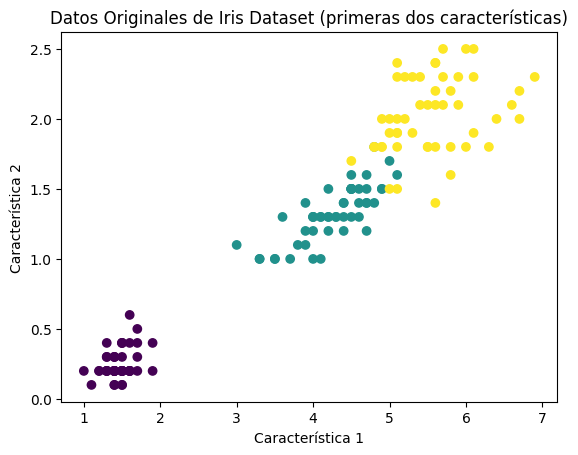

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.title('Datos Originales de Iris Dataset (primeras dos características)')
plt.show()

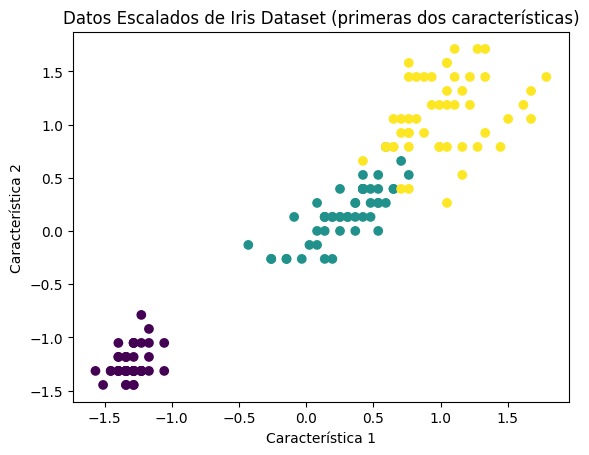

In [5]:
# Visualizar los resultados del clustering
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='viridis')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.title('Datos Escalados de Iris Dataset (primeras dos características)')
plt.show()

## Algoritmos Basados en Jerarquías

In [6]:
linkage_matrix = linkage(X_scaled, metric='euclidean', method='complete')

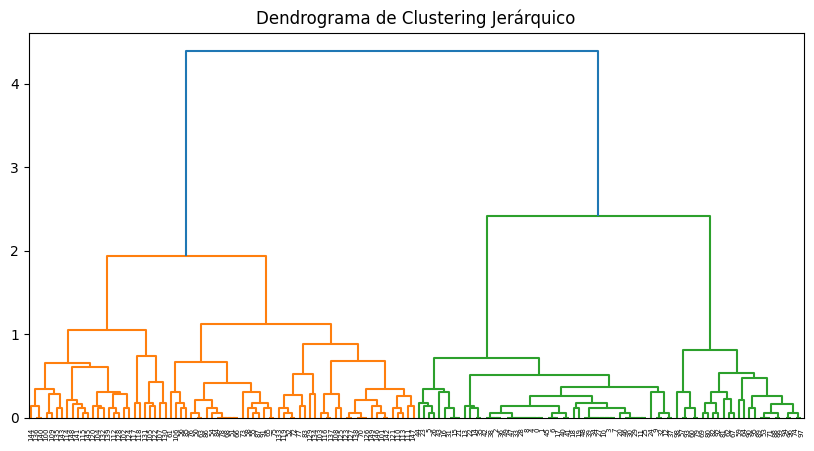

In [7]:
# Crear un dendrograma para visualizar el clustering jerárquico
plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix)
plt.title('Dendrograma de Clustering Jerárquico')
plt.show()


In [8]:
n_clusters = 3
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, metric='euclidean', linkage='complete')
cluster_labels = agg_clustering.fit_predict(X_scaled)

In [9]:
print(f'Clusters asignados (Etiquetas de Cluster): {cluster_labels}')

Clusters asignados (Etiquetas de Cluster): [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 1 0 0 0 1 0 1 1 0 1 0 1 0 0 1 0 1 0 1 0 0
 1 0 0 0 0 1 1 1 1 0 0 0 0 0 1 1 1 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


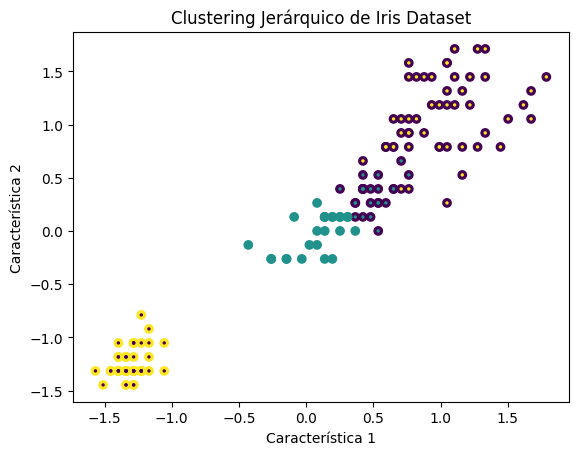

In [10]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=cluster_labels, cmap='viridis')
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='viridis', s = 2)
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.title('Clustering Jerárquico de Iris Dataset')
plt.show()

## Algoritmos Basados en Particiones

In [11]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, n_init = 10, random_state=0)
cluster_labels = kmeans.fit_predict(X_scaled)

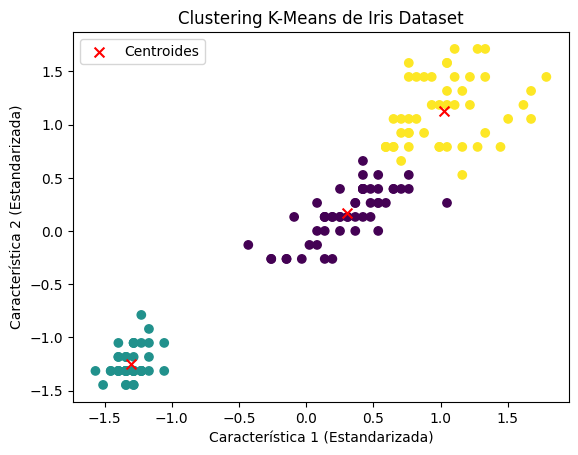

In [12]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=cluster_labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=50, c='red', marker='x', label='Centroides')
plt.xlabel('Característica 1 (Estandarizada)')
plt.ylabel('Característica 2 (Estandarizada)')
plt.title('Clustering K-Means de Iris Dataset')
plt.legend()
plt.show()

In [13]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

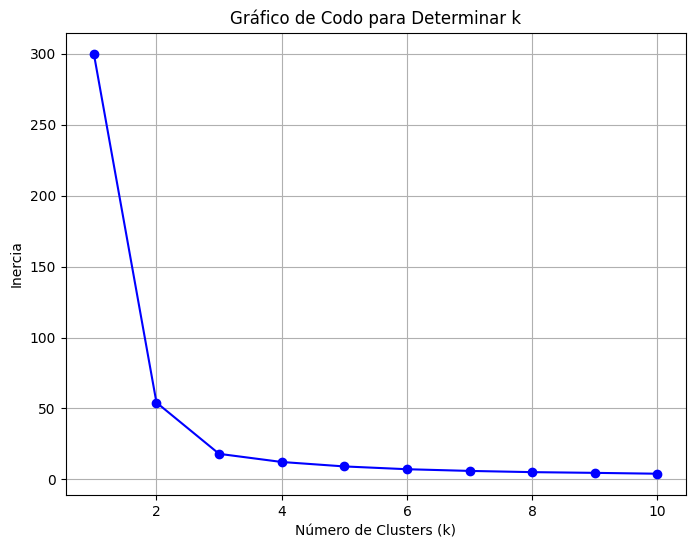

In [14]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='-', color='b')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Gráfico de Codo para Determinar k')
plt.grid(True)
plt.show()

## Algoritmos Basados en Densidad: DBScan

In [15]:
db = DBSCAN(eps=0.3,
            min_samples=5,
            metric='euclidean')
cluster_labels = db.fit_predict(X_scaled)

In [16]:
print("Etiquetas predichas:\n", cluster_labels)

Etiquetas predichas:
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1]


/tmp/ipython-input-2439197943.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


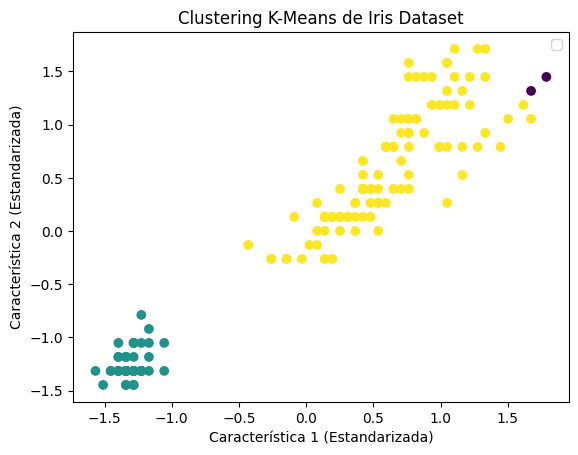

In [17]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=cluster_labels)
plt.xlabel('Característica 1 (Estandarizada)')
plt.ylabel('Característica 2 (Estandarizada)')
plt.title('Clustering K-Means de Iris Dataset')
plt.legend()


## Ahora una versión más completa

In [18]:
X_cpl = iris.data

In [19]:
scaler = StandardScaler()
X_cpl_scaled = scaler.fit_transform(X_cpl)

In [20]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, n_init = 10, random_state=0)
cluster_labels = kmeans.fit_predict(X_cpl_scaled)

In [21]:
pca = PCA(n_components=2)
X_r = pca.fit_transform(X_cpl_scaled)

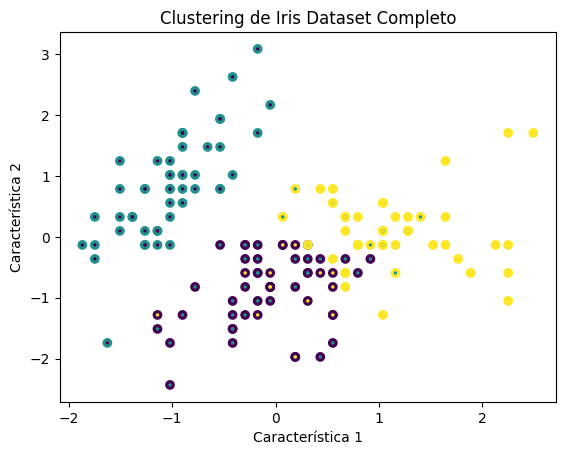

In [22]:
plt.scatter(X_cpl_scaled[:, 0], X_cpl_scaled[:, 1], c=cluster_labels, cmap='viridis')
plt.scatter(X_cpl_scaled[:, 0], X_cpl_scaled[:, 1], c=y, cmap='viridis', s = 2)
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.title('Clustering de Iris Dataset Completo')
plt.show()

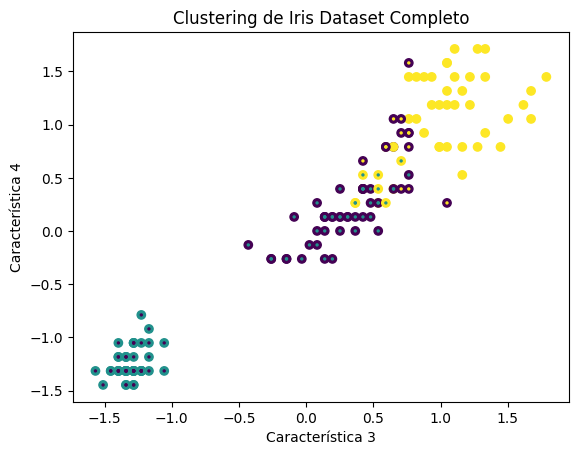

In [23]:
plt.scatter(X_cpl_scaled[:, 2], X_cpl_scaled[:, 3], c=cluster_labels, cmap='viridis')
plt.scatter(X_cpl_scaled[:, 2], X_cpl_scaled[:, 3], c=y, cmap='viridis', s = 2)
plt.xlabel('Característica 3')
plt.ylabel('Característica 4')
plt.title('Clustering de Iris Dataset Completo')
plt.show()

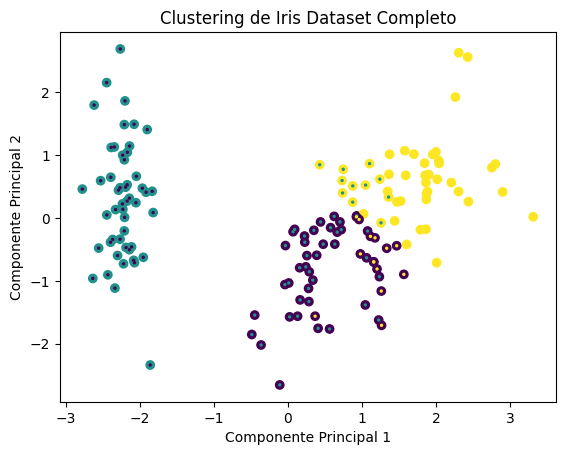

In [24]:
plt.scatter(X_r[:, 0], X_r[:, 1], c=cluster_labels, cmap='viridis')
plt.scatter(X_r[:, 0], X_r[:, 1], c=y, cmap='viridis', s = 2)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Clustering de Iris Dataset Completo')
plt.show()